# Liquidity Duration on Morpho Blue (Ethereum)
### Measuring Capital Stickiness Beyond TVL

---

**Author:** Ronith Yalamanchili  
**Date:** 26 March 2026  
**Scope:** Morpho Blue — Ethereum Mainnet Only  
**Data Source:** Dune Analytics (Query IDs: 6871840, 6872058, 6872073)  
**Coverage:** 27 depositor cohorts | 23 loan tokens | 117 weeks of flow data

---

> *This analysis is independent and exploratory. It is based entirely on publicly available on-chain data. The findings and any implied interpretations are those of the author and do not constitute investment advice. NOT FINANCIAL ADVICE*


## 1. Executive Summary

This report examines the duration and behavioral characteristics of liquidity deposited into Morpho Blue's Ethereum markets between January 2024 and March 2026. Using three on-chain metrics — cohort retention, USD-weighted deposit age, and weekly flow sensitivity — we attempt to assess whether Morpho's liquidity base displays properties more consistent with short-term yield-seeking behavior or longer-duration capital allocation.

**Key findings:**

- Early depositor cohorts (January–June 2024) exhibit 90-day retention rates of approximately **35%–45%**, compared to roughly **~10%** for cohorts entering later. This bifurcation suggests that Morpho's early user base has been meaningfully more persistent than subsequent cohorts.
- Across an estimated **$225.9B in gross cumulative USDC supply-event volume** from January 2024 to March 2026, the **USD-weighted average deposit age is 192.6 days**. This is a measure of capital longevity, not current TVL.
- Of 117 rolling weeks analyzed, **38 weeks (32.5%)** were classified as exhibiting organic inflows — defined as positive net USDC inflows occurring during weeks in which the prevailing borrow rate declined week-over-week.

These observations are consistent with a protocol that attracts a subset of capital with longer hold horizons and limited immediate rate sensitivity. They do not, by themselves, establish causality or rule out alternative explanations. The limitations section discusses each caveat in detail.


## 2. Why Duration Matters

Total Value Locked (TVL) is the dominant metric used to evaluate DeFi lending protocols. It answers a simple question: how much capital is deposited at a given point in time? What it does not measure is how long that capital stays, or whether it would remain under adverse conditions such as rate compression, market drawdowns, or competitive yield alternatives.

For the purposes of evaluating whether a DeFi lending protocol can serve as a stable credit layer — rather than as a temporary vehicle for yield optimization — duration and behavioral stability of deposited capital may be more informative than TVL alone.

This analysis introduces three complementary metrics:

1. **Cohort Retention Rate** — Do depositors re-engage with the protocol over multi-week horizons after their initial deposit?
2. **USD-Weighted Average Deposit Age** — How long has the average dollar of deposited capital been in the protocol, weighted by deposit size?
3. **Flow Sensitivity** — Does net capital inflow correlate positively or negatively with borrow rate movements, and what proportion of weeks see inflows even when rates are falling?

No single metric is definitive. Each of these approaches has methodological limitations, which are discussed in Section 5.


## 3. Methodology

### 3.1 Dataset Construction

All data is sourced from Morpho Blue's Ethereum deployment via Dune Analytics. Three separate queries were written and executed:

| Query ID | Description | Link |
|---|---|---|
| [6871840](https://dune.com/queries/6871840) | Cohort retention: monthly depositor cohorts, 30- and 90-day re-engagement | https://dune.com/queries/6871840 | 
| [6872058](https://dune.com/queries/6872058) | USD-weighted deposit age by loan token | https://dune.com/queries/6872058 |
| [6872073](https://dune.com/queries/6872073) | Weekly net USDC flows classified against borrow rate changes | https://dune.com/queries/6872073 |

**All Dune queries are publicly accessible. The analysis can be fully reproduced from publicly available on-chain data.*

### 3.2 Addressing the Vault Abstraction Problem

Morpho's MetaMorpho layer abstracts individual depositors behind ERC-4626 vault contracts. Naively reading `morphoblue_evt_supply` would record each vault as a single depositor — dramatically overstating concentration and potentially distorting retention metrics.

To partially correct for this, the cohort retention query unions `morphoblue_evt_supply` with `metamorpho_evt_deposit`, using the `owner` field in MetaMorpho deposit events to attribute activity to underlying depositor addresses. This approach reduces — but does not eliminate — the abstraction problem. Intermediate smart contracts, aggregators, and automated strategies may still obscure the true end-user.

### 3.3 Key Metric Definitions

**Cohort Retention:** A depositor is grouped by the calendar month of their first observed supply event. They are counted as "retained" at the 30-day or 90-day mark if they execute any additional supply event within a ±5-day window around that mark. This is a conservative measure: a depositor whose funds remain in the protocol but who never executes another supply transaction will appear as not retained.

**USD-Weighted Average Deposit Age:** For each supply event, the deposit age is computed as the number of days between the event timestamp and the query snapshot date. The age is then weighted by the USD value of each deposit. This gives greater weight to larger, older deposits relative to smaller or more recent ones. Conceptually, this measures how long the average USDC dollar has been in Morpho, with larger deposits having proportionally more influence on the metric.

**Flow Sensitivity / Organic Inflows:** Weeks are classified based on the combination of net USDC flows and week-over-week borrow rate changes:
- *Organic inflow*: net flows are positive AND borrow rate declined
- *Rate-chasing inflow*: net flows are positive AND borrow rate rose
- *Withdrawal (rate drop)*: net flows are negative AND borrow rate declined
- *Withdrawal (rate rise)*: net flows are negative AND borrow rate rose

**Cumulative Supply-Event Volume:** This is the gross sum of all individual supply events, unadjusted for withdrawals or redemptions. It represents total protocol throughput over the measurement period, not current balances or TVL.


## 4. Findings

### Setup & Data Loading


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.family'] = 'sans-serif'

DATA_DIR = Path('../data')
df_retention = pd.read_csv(DATA_DIR / 'morpho_retention_cohorts.csv')
df_age       = pd.read_csv(DATA_DIR / 'morpho_deposit_age.csv')
df_flows     = pd.read_csv(DATA_DIR / 'morpho_flow_sensitivity.csv')

df_retention['cohort_month'] = pd.to_datetime(df_retention['cohort_month'])
df_flows['week'] = pd.to_datetime(df_flows['week'])

print(f'Cohorts:  {len(df_retention)}')
print(f'Tokens:   {len(df_age)}')
print(f'Weeks:    {len(df_flows)}')


Cohorts:  27
Tokens:   23
Weeks:    117


### 4.1 Cohort Retention

**What was measured:** Monthly cohorts of Morpho Blue depositors on Ethereum, tracked for re-engagement at 30 and 90 days following their first observed supply event. 27 cohorts are captured across the study window.


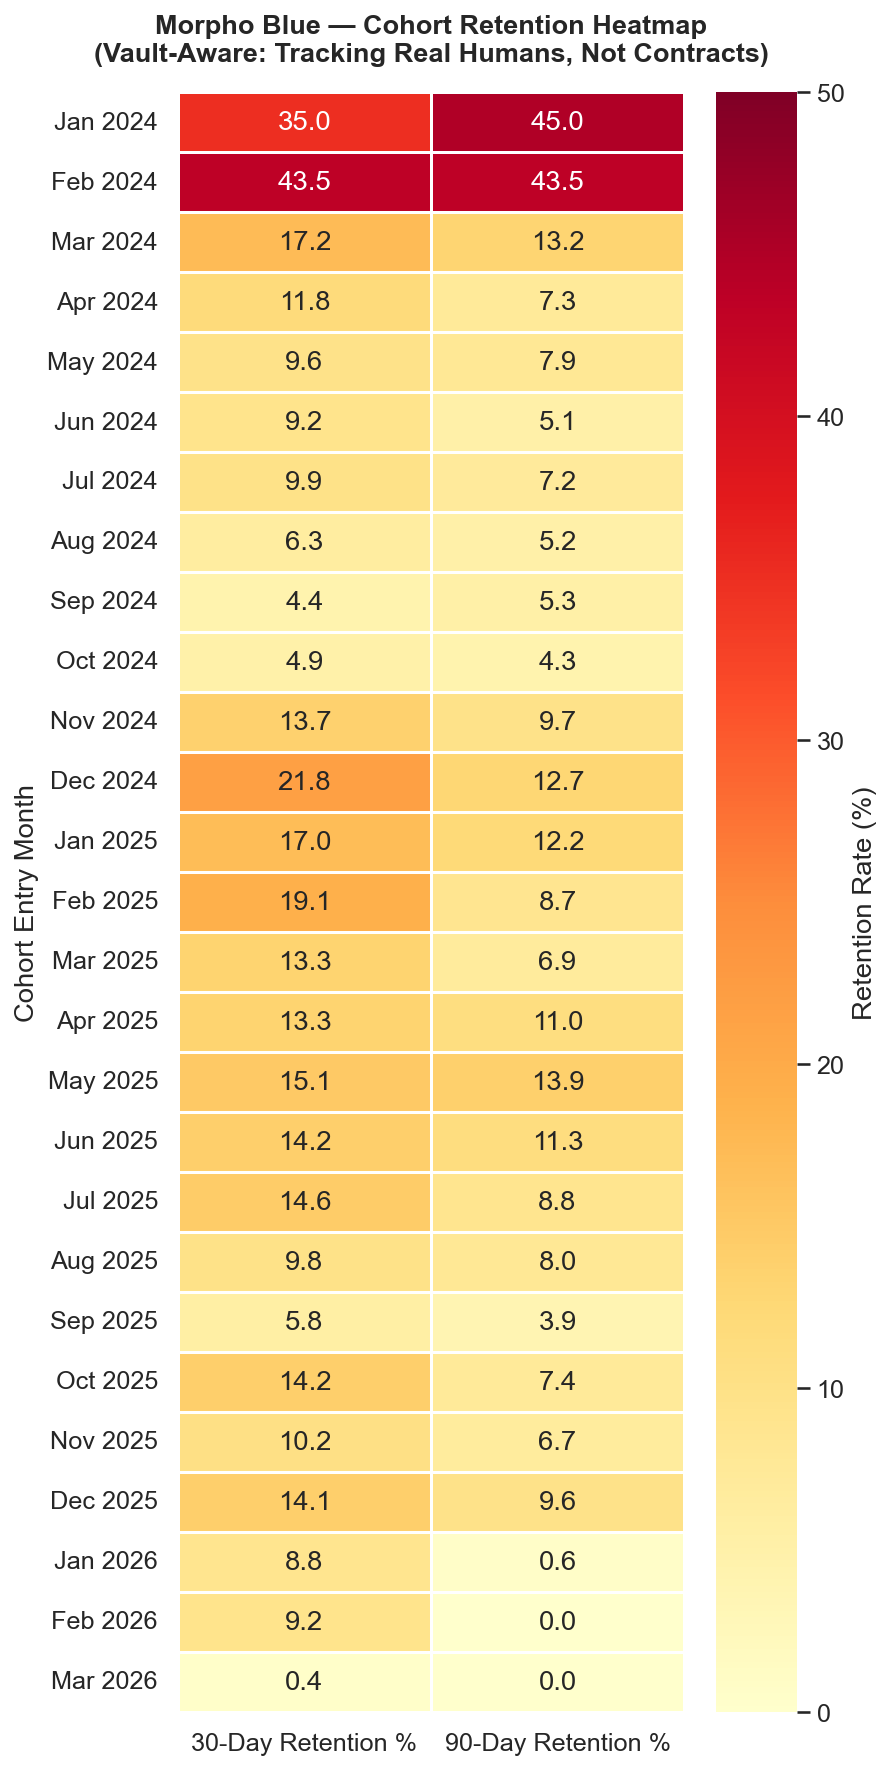

In [8]:
# Prepare heatmap data
heatmap_df = df_retention.sort_values('cohort_month').copy()
heatmap_df['label'] = heatmap_df['cohort_month'].dt.strftime('%b %Y')

# Build the matrix
heat_data = heatmap_df.set_index('label')[['retention_rate_30d_pct', 'retention_rate_90d_pct']]
heat_data.columns = ['30-Day Retention %', '90-Day Retention %']

fig, ax = plt.subplots(figsize=(6, 12))

sns.heatmap(
    heat_data.astype(float),
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'},
    ax=ax,
    vmin=0,
    vmax=50
)

ax.set_title('Morpho Blue — Cohort Retention Heatmap\n(Vault-Aware: Tracking Real Humans, Not Contracts)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Cohort Entry Month')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig(DATA_DIR / 'chart_retention_heatmap.png')
plt.show()

**Results:** The heatmap reveals a consistent pattern across 27 cohorts. Depositors who first entered the protocol between January and June 2024 display 90-day retention rates in the **35%–45% range**. Cohorts entering from mid-2025 onward show materially lower retention, converging toward **~10%** for the most recent cohorts.

**Interpretation:** The divergence across cohort vintages is consistent with two possible explanations: (1) early adopters disproportionately represent more sophisticated or institutionally-oriented allocators with longer hold horizons; (2) the protocol's user composition has shifted over time toward a broader, higher-turnover base. Both explanations may operate simultaneously and are not mutually exclusive.

**What this does not establish:** Retention here is defined narrowly as re-supplying within a ±5-day window. Capital that remains in the protocol without generating additional supply events is not counted as retained. This measurement likely understates passive stickiness. It also does not control for the size of deposits; a single large allocator returning once would count identically to a small retail user.


### 4.2 USD-Weighted Average Deposit Age

**What was measured:** For each supply event, deposit age was computed as the number of days from the event timestamp to the snapshot date. Ages were then aggregated weighted by USD deposit value, such that larger deposits contribute more to the overall average.


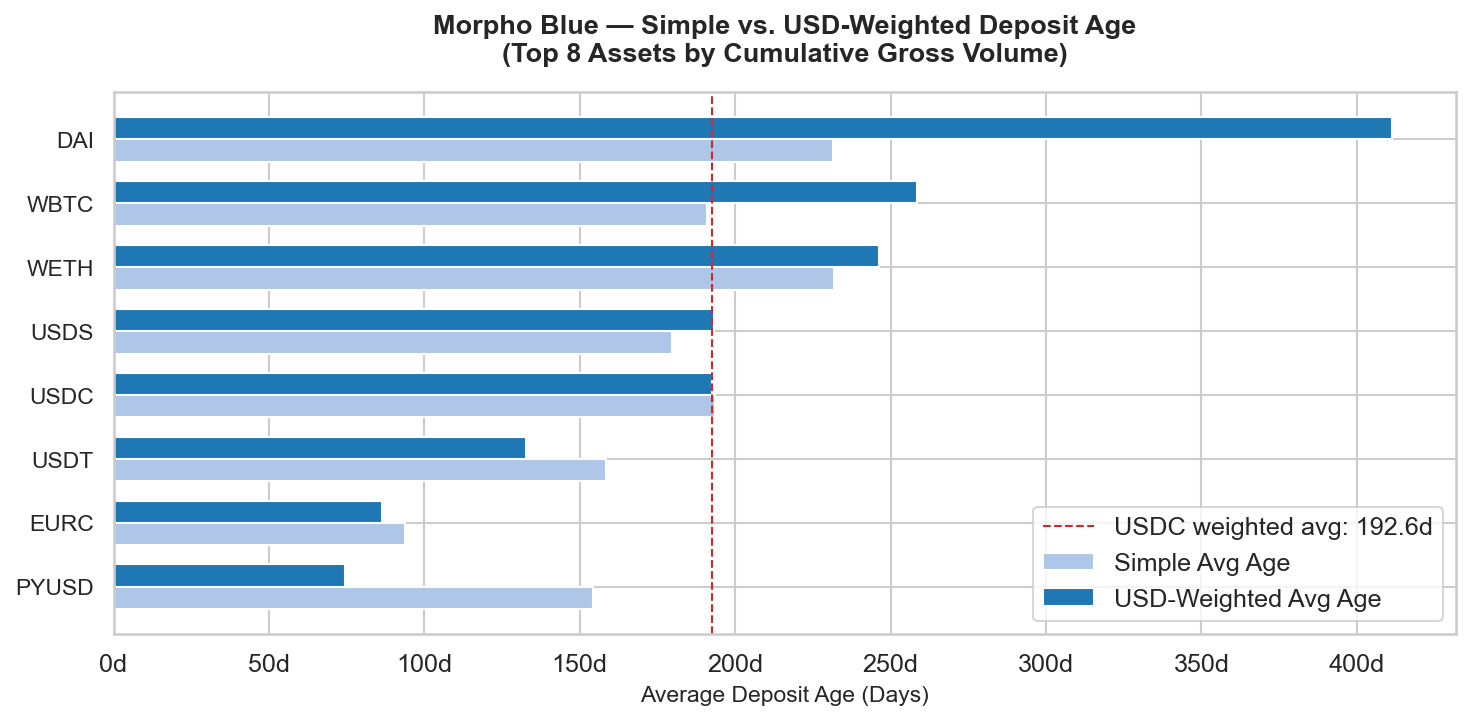

USDC: gross volume $225.9B | simple avg 193.6d | weighted avg 192.6d | depositors 1008


In [5]:
# ── Deposit Age Chart ──
top_tokens = df_age.nlargest(8, 'total_usd_deposited').copy()
top_tokens = top_tokens.sort_values('usd_weighted_avg_age_days', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(top_tokens))
bar_w = 0.35

ax.barh(y_pos - bar_w/2, top_tokens['simple_avg_age_days'],   bar_w, label='Simple Avg Age',      color='#aec6e8', edgecolor='white')
ax.barh(y_pos + bar_w/2, top_tokens['usd_weighted_avg_age_days'], bar_w, label='USD-Weighted Avg Age', color='#1f77b4', edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_tokens['token_symbol'], fontsize=11)
ax.set_xlabel('Average Deposit Age (Days)', fontsize=11)
ax.set_title(
    'Morpho Blue — Simple vs. USD-Weighted Deposit Age\n(Top 8 Assets by Cumulative Gross Volume)',
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(loc='lower right', frameon=True)

usdc_row = df_age[df_age['token_symbol'] == 'USDC'].iloc[0]
ax.axvline(usdc_row['usd_weighted_avg_age_days'], color='#d62728', linestyle='--', linewidth=1, label=f'USDC weighted avg: {usdc_row["usd_weighted_avg_age_days"]:.1f}d')
ax.legend(loc='lower right', frameon=True)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}d'))
plt.tight_layout()
plt.savefig('../data/chart_deposit_age.png', dpi=150)
plt.show()

print(f"USDC: gross volume ${usdc_row['total_usd_deposited']/1e9:.1f}B | simple avg {usdc_row['simple_avg_age_days']:.1f}d | weighted avg {usdc_row['usd_weighted_avg_age_days']:.1f}d | depositors {int(usdc_row['unique_depositors'])}")


**Results:** USDC is the dominant loan token, with approximately **$225.9B in gross cumulative supply-event volume**, contributed by **1,008 unique depositor addresses** over the study period. The USD-weighted average deposit age for USDC is **192.6 days**; the simple (unweighted) average is 193.6 days. The convergence of the two averages suggests that deposit age does not appear skewed by a small number of outsized long-duration positions.

*Important framing note:* The $225.9B figure is gross cumulative inflow — the sum of all individual supply transactions from January 2024 to March 2026, before any withdrawals or redemptions. This is not a TVL figure. Morpho's current total deposits across all chains are reported in the $7–11B range. In high-turnover stablecoin lending, cumulative gross flow over multiple years can far exceed point-in-time outstanding balances.

**Interpretation:** A USD-weighted average deposit age of 192.6 days indicates that, when capital size is accounted for, the average dollar of USDC has been in a Morpho market for approximately six months. This is notable for a permissionless lending protocol. The interpretation depends on whether this duration reflects intentional, long-horizon allocation or simply low activity from dormant positions.

**What this does not establish:** Deposit age is not equivalent to a commitment to remain. Capital may have remained in the protocol not from conviction but due to inattention, UI friction, or lock-in effects associated with downstream integrations. The metric also does not distinguish between active positions and positions that may have been forgotten.


### 4.3 Flow Sensitivity

**What was measured:** For each of the 117 weeks in the study window, we computed net USDC flows into Morpho Blue (Ethereum) and classified them in combination with the direction of the week-over-week borrow rate change.


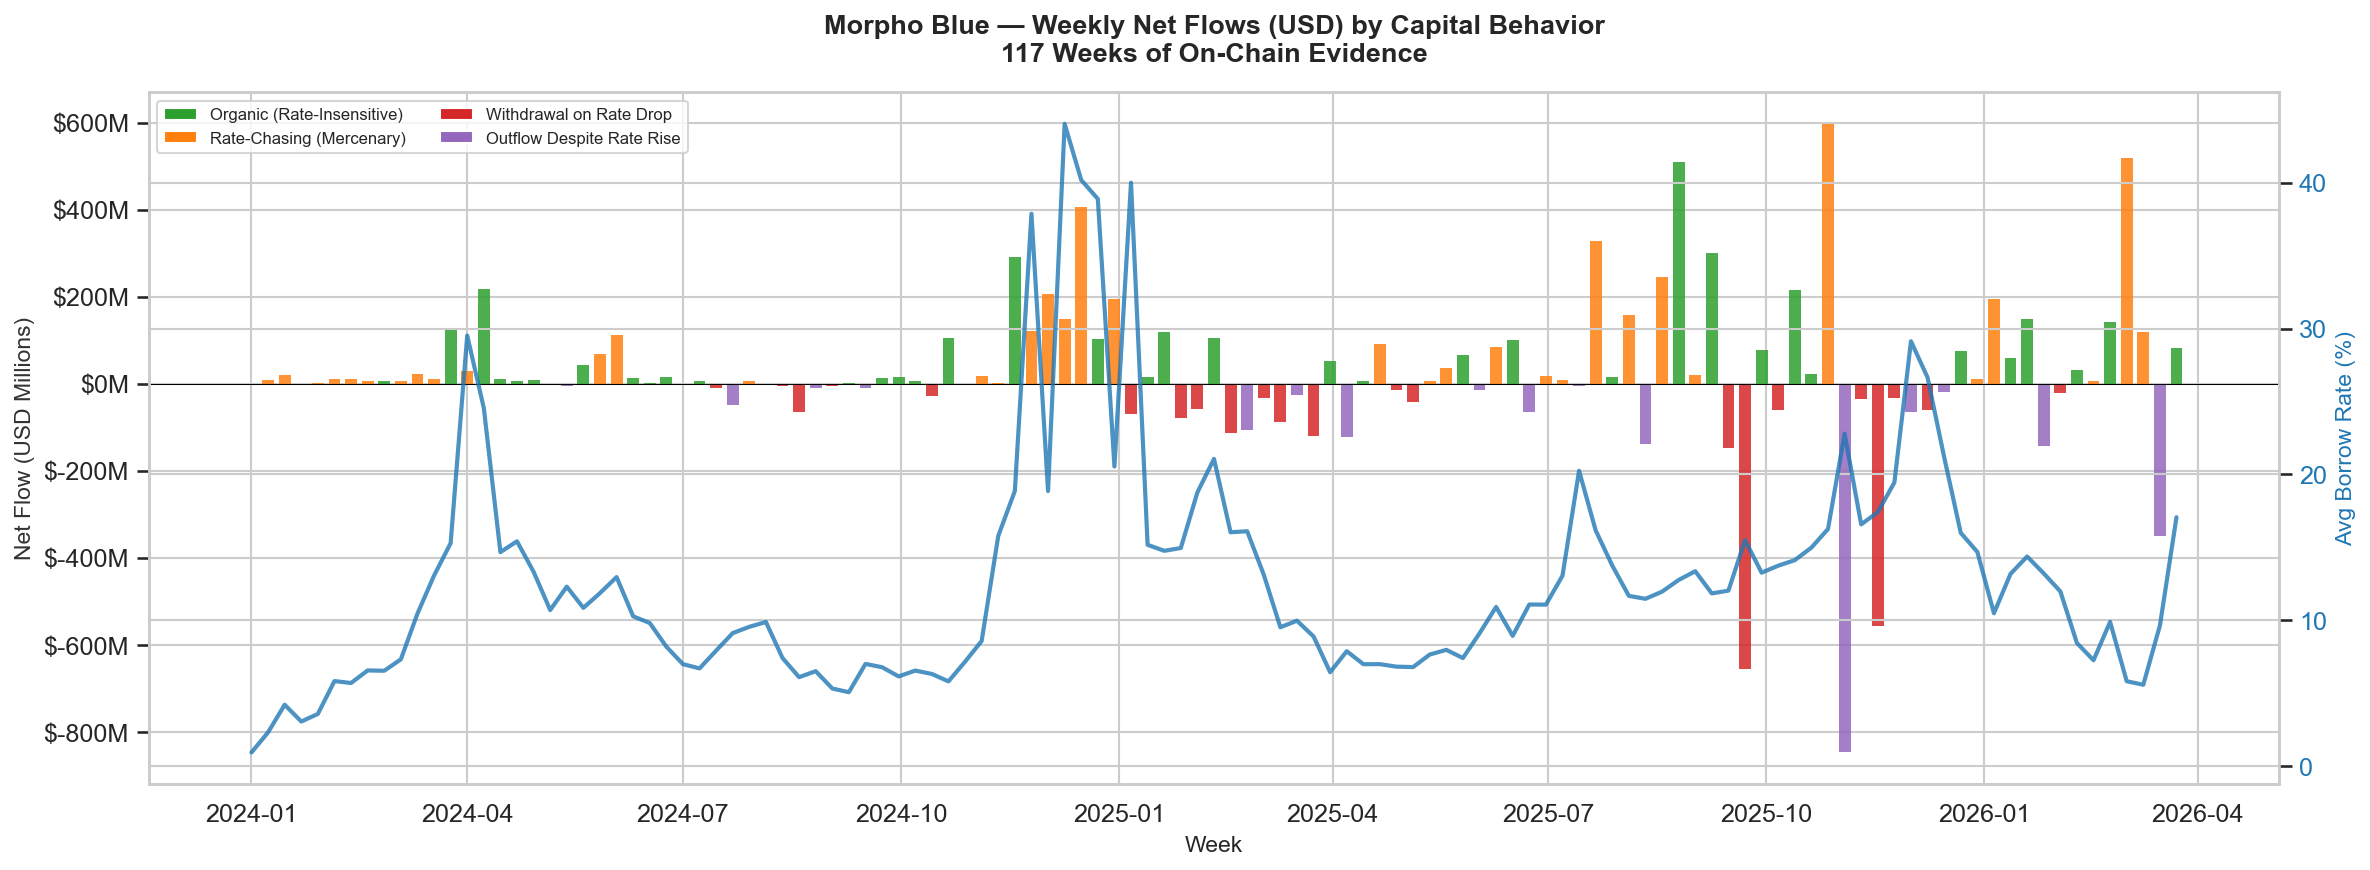


Behavior Distribution (117 weeks):
  Organic (Rate-Insensitive): 38 weeks (32.5%)
  Rate-Chasing (Mercenary): 36 weeks (30.8%)
  Withdrawal on Rate Drop: 25 weeks (21.4%)
  Outflow Despite Rate Rise: 17 weeks (14.5%)
  Flat / No Change: 1 weeks (0.9%)

→ 32% of weeks show Organic, rate-insensitive capital inflows.


In [9]:
# Sort by date
flow_df = df_flows.sort_values('week').copy()

# Color mapping for behavior labels
color_map = {
    'Organic (Rate-Insensitive)': '#2ca02c',
    'Rate-Chasing (Mercenary)': '#ff7f0e', 
    'Withdrawal on Rate Drop': '#d62728',
    'Outflow Despite Rate Rise': '#9467bd',
    'Flat / No Change': '#7f7f7f'
}

bar_colors = flow_df['flow_behaviour_label'].map(color_map).fillna('#7f7f7f')

fig, ax1 = plt.subplots(figsize=(16, 6))

# Bar chart: Net flows
ax1.bar(flow_df['week'], flow_df['net_flow_usd'] / 1e6, 
        width=5, color=bar_colors, alpha=0.85, edgecolor='none')
ax1.set_ylabel('Net Flow (USD Millions)', fontsize=11, color='#333')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))

# Overlay line: Borrow rate (only if we have real rate data)
if 'avg_borrow_rate_pct' in flow_df.columns and flow_df['avg_borrow_rate_pct'].sum() > 0:
    ax2 = ax1.twinx()
    ax2.plot(flow_df['week'], flow_df['avg_borrow_rate_pct'], 
             color='#1f77b4', linewidth=2, alpha=0.8, label='Avg Borrow Rate %')
    ax2.set_ylabel('Avg Borrow Rate (%)', fontsize=11, color='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')

ax1.set_title('Morpho Blue — Weekly Net Flows (USD) by Capital Behavior\n'
              '117 Weeks of On-Chain Evidence', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Week', fontsize=11)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items() if l != 'Flat / No Change']
ax1.legend(handles=legend_elements, loc='upper left', fontsize=8, frameon=True, ncol=2)

plt.tight_layout()
plt.savefig(DATA_DIR / 'chart_flow_sensitivity.png')
plt.show()

# Summary: count behavior types
behavior_counts = flow_df['flow_behaviour_label'].value_counts()
total_weeks = len(flow_df)
organic_pct = 100 * behavior_counts.get('Organic (Rate-Insensitive)', 0) / total_weeks

print(f"\nBehavior Distribution ({total_weeks} weeks):")
for label, count in behavior_counts.items():
    print(f"  {label}: {count} weeks ({100*count/total_weeks:.1f}%)")
print(f"\n→ {organic_pct:.0f}% of weeks show Organic, rate-insensitive capital inflows.")

**Results:** Of 117 weeks analyzed, **38 (32.5%)** are classified as organic inflow weeks — defined as weeks in which net USDC flows were positive while the borrow rate fell week-over-week. The two largest outflow events — approximately -$847M and -$556M in consecutive weeks during November 2025 — coincided with a period of broad market de-risking rather than a Morpho-specific rate change. Capital flows recovered to positive territory within subsequent weeks.

**Interpretation:** The 32.5% organic inflow share indicates that a meaningful proportion of weekly capital entry is not immediately explained by rate improvements. This pattern is consistent with — though does not prove — the presence of allocators whose capital deployment decisions are less sensitive to short-term yield movements. However, 32.5% also means that the majority of weeks (67.5%) show flows that do correlate with rate direction in some form. A claim of broad rate-insensitivity would be too strong.

**What this does not establish:** This analysis classifies weeks, not individual depositors. A given week could be driven by a single large institution making a rate-insensitive allocation, while retail participants simultaneously respond to rate changes — and vice versa. The flow-rate correlation analysis is descriptive, not structural; other variables driving both rates and flows (e.g., broader DeFi liquidity conditions, protocol incentives, macro events) are not controlled for.


## 5. Limitations

The following limitations should be weighed when interpreting these findings:

1. **Cumulative volume is not TVL.** The $225.9B USDC figure represents gross supply-event volume over approximately 26 months. It is not net of withdrawals and should not be compared to current TVL. Morpho's current total deposits are reported in the $7–11B range across chains.

2. **Address tracing is imperfect.** Attributing MetaMorpho vault deposits to underlying `owner` addresses improves depositor identification but cannot fully resolve all abstraction layers. Aggregators, automated strategies, and custodians may still appear as a single depositor address, potentially inflating or distorting retention and depositor count metrics.

3. **Retention is conservatively defined.** A depositor who maintains funds in the protocol without executing additional supply events is counted as not retained. This likely understates passive capital persistence. The metric captures re-engagement activity, not capital presence.

4. **Flow analysis is correlational.** The organic/rate-chasing classification is based on directional co-movement of net flows and borrow rates. It does not identify causal mechanisms. External factors — including token incentive programs, macro risk events, competitive yield alternatives, or large individual allocators — could drive both metrics simultaneously without implying rate-insensitive behavior on the part of the depositor base broadly.

5. **Ethereum-only scope.** This study covers Morpho Blue's Ethereum mainnet deployment. Morpho has since expanded to Base, Arbitrum, Hyperliquid, and other networks. Cross-chain depositor behavior may differ materially and is not captured here.

6. **Point-in-time snapshot.** The deposit age computation reflects conditions as of the query snapshot date in March 2026. It does not represent a time-series of historical weighted ages and may not generalize to future periods.


## 6. Conclusion

The three metrics analyzed in this report — cohort retention, USD-weighted deposit age, and flow sensitivity — each provide partial evidence on the question of capital duration in Morpho Blue's Ethereum markets.

| Metric | Observation | Caveat |
|---|---|---|
| **Cohort Retention** | Early cohorts (Jan–Jun 2024) show 35%–45% 90-day retention; later cohorts ~10% | Conservative measure; doesn't capture passive holders |
| **USD-Weighted Deposit Age** | 192.6 days on $225.9B gross USDC inflows (Jan 2024–Mar 2026) | Gross volume, not TVL; duration ≠ commitment |
| **Flow Sensitivity** | 38 of 117 weeks (32.5%) show organic inflows during rate declines | Correlational; majority of weeks still show rate-sensitive flows |

Taken together, the data is consistent with the view that Morpho Blue's depositor base on Ethereum includes a subset of capital with longer hold horizons and limited immediate sensitivity to borrow rate movements. The early cohort retention bifurcation suggests this characteristic may be concentrated among participants who entered early in the protocol's lifecycle.

These findings raise but do not resolve the question of what drives duration-stable behavior — whether protocol design, depositor composition, downstream integration dynamics, or other factors. Further work, including cross-chain analysis and depositor-level segmentation, would be required to draw stronger conclusions.

---



## 7. Coming Up: Next Steps in This Series

This note is intentionally narrow: it focuses on Morpho Blue’s Ethereum deployment and relies on address-level behavior rather than entity-level identification. Several of the key open questions it raises can be addressed with further work.

In future work, I plan to:

- **Introduce cross-protocol benchmarks.** Apply the same cohort, duration, and flow-sensitivity framework to comparable markets on Aave, Spark, and other major lending venues to understand whether Morpho’s metrics are meaningfully differentiated or simply typical for scaled DeFi credit platforms.

- **Run sensitivity analyses on retention definitions.** Test alternative re-engagement windows (for example ±15 days) and additional retention metrics based on balance persistence to quantify how much the current ±5-day definition understates passive stickiness.

- **Segment depositor types more explicitly.** Where possible, separate large vaults, aggregators, custodians, and EOAs to distinguish genuine end-allocators from routing or execution infrastructure. This will help clarify whether observed duration is concentrated in a small number of strategy addresses or more broadly distributed.

- **Extend the analysis cross-chain.** Replicate the framework for Morpho deployments on Base, Arbitrum, Hyperliquid, and other supported networks to test whether Ethereum behavior generalizes or whether duration characteristics are chain-specific.

Collectively, these extensions should help move the analysis from a single-protocol case study toward a more comparative view of duration-stable liquidity in on-chain credit markets.

## 8. Thank You

Thank you so much for reading ! Would appreciate any feedback -> contact info below !

https://dune.com/0xronman | https://x.com/ronman_chili | https://linkedin.com/in/ronith-ry
